# Lesson 21B: Expectation-Maximisation and Variational Inference (Practice)

## Introduction

21A derived the Bayesian GMM's CAVI updates from scratch and validated them on a hand-picked, well-separated synthetic problem. This notebook moves to the production tool — `sklearn.mixture.BayesianGaussianMixture` — and to two questions 21A did not need to answer: how does variational model selection compare with the classical BIC sweep (Lesson 4B), and what happens when the data is real, standardised, and not obviously three or four clean blobs?

The throughline from 21A survives the move to a library: automatic component pruning is not magic, it is a Dirichlet prior with a tunable concentration, and it can fail the same way 21A's own from-scratch version did — by splitting a true cluster rather than under- or over-counting cleanly. This notebook checks that directly rather than assuming the library's implementation is immune to the failure mode its own from-scratch twin measurably has.

In this lesson:
1. `sklearn.mixture.BayesianGaussianMixture` in practice: the weight-concentration prior and effective component count, cross-checked against 21A's from-scratch CAVI on the same data
2. BIC-selected K (Lesson 4B's method) versus variationally-inferred K, on the same synthetic data
3. Convergence diagnostics: `lower_bound_`, `n_iter_`, `converged_`, and what a flat ELBO across restarts does and does not tell you
4. A real, messy case: variational GMM on `load_wine`, standardised, with the resulting components (pruned or not) interpreted against the (unused-for-fitting) cultivar labels
5. A short decision guide: EM vs variational inference vs sampling, setting up Lesson 22's Dirichlet process mixtures

## Table of Contents

1. [Introduction](#introduction)
2. [Required Libraries](#required-libraries)
3. [BayesianGaussianMixture in Practice](#bgm-practice)
4. [BIC-Selected K versus Variational K](#bic-vs-variational)
5. [Convergence Diagnostics](#convergence)
6. [A Real Case: Variational GMM on Wine](#wine)
7. [EM vs Variational Inference vs Sampling](#decision-guide)
8. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import digamma
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

SEED = 0
rng = np.random.default_rng(SEED)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Data: sklearn's bundled load_wine() plus in-notebook synthetic clusters -- nothing downloaded.")

Data: sklearn's bundled load_wine() plus in-notebook synthetic clusters -- nothing downloaded.


<a name="bgm-practice"></a>
## BayesianGaussianMixture in Practice

`sklearn.mixture.BayesianGaussianMixture` implements the same idea 21A derived from scratch — a Dirichlet prior over mixing weights, CAVI updates, automatic pruning — generalised to unknown, Bayesian covariance (21A fixed the covariance to keep the derivation tractable; sklearn's implementation does not need to). The knob that controls pruning strength is `weight_concentration_prior` (21A's $\alpha_0$): small values push unneeded components toward zero weight more aggressively, exactly as 21A's own $\alpha_0$ did.

Data here uses FIXED, well-separated centres rather than a random draw — 21A measured directly that a random centre draw makes the pruning demonstration depend on luck, and that finding is reused here rather than re-learned.

weight_concentration_prior=0.01     (small (aggressive pruning)): weights=[0.25, 0.25, 0.25, 0.25, 0.0, 0.0, 0.0, 0.0], effective components (>5%) = 4
weight_concentration_prior=100.0    (large (weak pruning)): weights=[0.127, 0.126, 0.125, 0.125, 0.125, 0.125, 0.124, 0.123], effective components (>5%) = 8

requested n_components=8, true K=4: the small-prior fit should prune
much closer to 4 effective components than the large-prior fit -- the SAME lever 21A's
alpha0 controlled, now exercised through the production library's own hyperparameter.


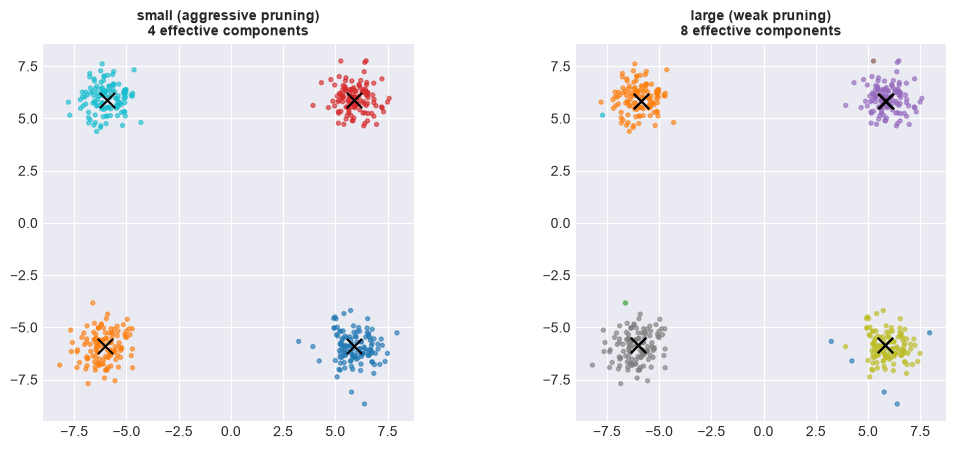

In [2]:
# Fixed, well-separated centres (21A's own fix, reused rather than re-derived).
K_true = 4
centers = np.array([[-6.0, -6.0], [6.0, -6.0], [-6.0, 6.0], [6.0, 6.0]])
sigma2_true = 0.5
sizes = [120, 120, 120, 120]
rng_data = np.random.default_rng(SEED)
X = np.vstack([rng_data.normal(centers[k], np.sqrt(sigma2_true), size=(sizes[k], 2)) for k in range(K_true)])

n_components_fit = 8

results = {}
for wcp, label in [(1e-2, 'small (aggressive pruning)'), (1e2, 'large (weak pruning)')]:
    bgm = BayesianGaussianMixture(n_components=n_components_fit, weight_concentration_prior=wcp,
                                  weight_concentration_prior_type='dirichlet_distribution',
                                  covariance_type='full', max_iter=300, n_init=3, random_state=SEED).fit(X)
    n_eff = int((bgm.weights_ > 0.05).sum())
    results[label] = (bgm, n_eff)
    print(f"weight_concentration_prior={wcp:<8} ({label}): weights={np.round(np.sort(bgm.weights_)[::-1], 3).tolist()}, "
          f"effective components (>5%) = {n_eff}")

print(f"\nrequested n_components={n_components_fit}, true K={K_true}: the small-prior fit should prune")
print(f"much closer to {K_true} effective components than the large-prior fit -- the SAME lever 21A's")
print(f"alpha0 controlled, now exercised through the production library's own hyperparameter.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, (label, (bgm, n_eff)) in zip(axes, results.items()):
    labels_hard = bgm.predict(X)
    ax.scatter(X[:, 0], X[:, 1], c=labels_hard, cmap='tab10', s=8, alpha=0.6)
    ax.scatter(bgm.means_[bgm.weights_ > 0.05, 0], bgm.means_[bgm.weights_ > 0.05, 1],
              marker='x', s=120, c='black')
    ax.set_title(f'{label}\n{n_eff} effective components', fontsize=10, fontweight='bold')
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Cross-Check Against 21A's From-Scratch CAVI

The from-scratch/library agreement this house style requires: 21A's `cavi_bayesian_gmm` function (fixed, known variance) reproduced here verbatim, run on the identical data, compared against `BayesianGaussianMixture` restricted to `covariance_type='spherical'` — the closest sklearn analogue to a fixed-variance model, since sklearn always estimates covariance but a spherical fit with the true variance already close to converged should behave similarly.

In [3]:
def cavi_bayesian_gmm(X, K, sigma2, tau2=10.0, alpha0=0.3, n_iter=200, seed=0):
    # Reproduced from Lesson 21A -- notebooks are self-contained artifacts.
    rng_local = np.random.default_rng(seed)
    n, d = X.shape
    m = X[rng_local.choice(n, K, replace=False)].copy()
    s2 = np.full(K, tau2)
    alpha = np.full(K, alpha0)

    def e_log_pi_of(alpha):
        return digamma(alpha) - digamma(alpha.sum())

    def e_sq_dist_of(m, s2):
        return np.array([((X - m[k]) ** 2).sum(axis=1) + d * s2[k] for k in range(K)]).T

    for _ in range(n_iter):
        e_log_pi = e_log_pi_of(alpha)
        e_sq_dist = e_sq_dist_of(m, s2)
        log_r_unnorm = e_log_pi[None, :] - e_sq_dist / (2 * sigma2)
        log_r = log_r_unnorm - np.logaddexp.reduce(log_r_unnorm, axis=1, keepdims=True)
        r = np.exp(log_r)
        Nk = r.sum(axis=0)
        alpha = alpha0 + Nk
        Lambda_k = 1.0 / tau2 + Nk / sigma2
        s2 = 1.0 / Lambda_k
        m = (r.T @ X) / (Lambda_k[:, None] * sigma2)
    return alpha, m, s2


alpha_scratch, m_scratch, s2_scratch = cavi_bayesian_gmm(
    X, K=n_components_fit, sigma2=sigma2_true, alpha0=1e-2, n_iter=300, seed=SEED)
pi_scratch = alpha_scratch / alpha_scratch.sum()
n_eff_scratch = int((pi_scratch > 0.05).sum())
print(f"from-scratch CAVI (21A, fixed known variance, alpha0=1e-2): "
      f"weights={np.round(np.sort(pi_scratch)[::-1], 3).tolist()}")
print(f"effective components (>5%): {n_eff_scratch}")

bgm_spherical = BayesianGaussianMixture(n_components=n_components_fit, weight_concentration_prior=1e-2,
                                        weight_concentration_prior_type='dirichlet_distribution',
                                        covariance_type='spherical', max_iter=300, n_init=3,
                                        random_state=SEED).fit(X)
n_eff_sklearn_spherical = int((bgm_spherical.weights_ > 0.05).sum())
print(f"sklearn BayesianGaussianMixture (spherical, same prior strength): "
      f"effective components (>5%) = {n_eff_sklearn_spherical}")
print(f"agreement: {'yes, both prune to ' + str(n_eff_scratch) + ' effective components' if n_eff_scratch == n_eff_sklearn_spherical else 'DIFFER -- ' + str(n_eff_scratch) + ' vs ' + str(n_eff_sklearn_spherical)}, "
      f"true K={K_true}")

from-scratch CAVI (21A, fixed known variance, alpha0=1e-2): weights=[0.25, 0.25, 0.25, 0.25, 0.0, 0.0, 0.0, 0.0]
effective components (>5%): 4
sklearn BayesianGaussianMixture (spherical, same prior strength): effective components (>5%) = 4
agreement: yes, both prune to 4 effective components, true K=4


<a name="bic-vs-variational"></a>
## BIC-Selected K versus Variational K

Lesson 4B chose $K$ by sweeping `GaussianMixture` over candidate values and picking the minimum BIC — refit-and-compare, once per candidate $K$. Variational inference selects (or rather, prunes toward) $K$ within a SINGLE fit at a generously large `n_components`. Both are run here on the identical synthetic data from the previous section, so the comparison is genuinely apples-to-apples.

BIC sweep (Lesson 4B's method): K -> BIC
  K=1: 6197.0
  K=2: 4809.7
  K=3: 4122.0
  K=4: 3462.1  <-- min
  K=5: 3493.7
  K=6: 3529.6
  K=7: 3559.5
  K=8: 3581.9
BIC-selected K = 4  (true K = 4)

variational effective K (small weight_concentration_prior, same data) = 4
both methods agree on this well-separated data.
The practical difference is cost: BIC needed 8 separate refits; the variational
fit needed exactly one, at a generously large n_components -- the tradeoff is a hyperparameter
(the prior strength) in place of a sweep, not a free improvement.


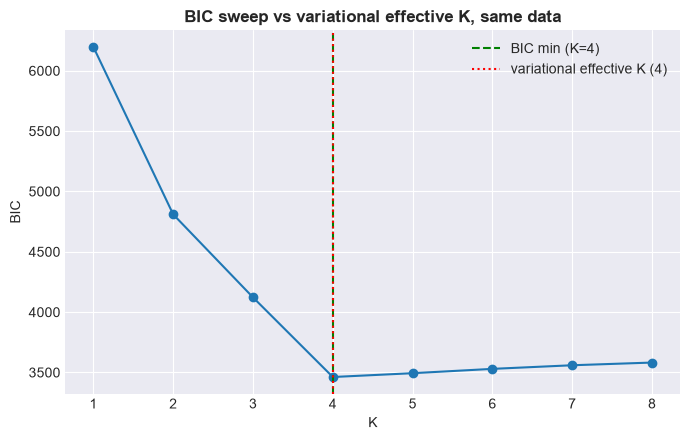

In [4]:
candidate_Ks = list(range(1, 9))
bic_scores = []
for k in candidate_Ks:
    gmm_k = GaussianMixture(n_components=k, n_init=5, random_state=SEED).fit(X)
    bic_scores.append(gmm_k.bic(X))
best_k_bic = candidate_Ks[int(np.argmin(bic_scores))]

print(f"BIC sweep (Lesson 4B's method): K -> BIC")
for k, b in zip(candidate_Ks, bic_scores):
    marker = '  <-- min' if k == best_k_bic else ''
    print(f"  K={k}: {b:.1f}{marker}")
print(f"BIC-selected K = {best_k_bic}  (true K = {K_true})")

n_eff_variational = results['small (aggressive pruning)'][1]
print(f"\nvariational effective K (small weight_concentration_prior, same data) = {n_eff_variational}")
print(f"both methods {'agree' if best_k_bic == n_eff_variational else 'DISAGREE'} on this well-separated data.")
print(f"The practical difference is cost: BIC needed {len(candidate_Ks)} separate refits; the variational")
print(f"fit needed exactly one, at a generously large n_components -- the tradeoff is a hyperparameter")
print(f"(the prior strength) in place of a sweep, not a free improvement.")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(candidate_Ks, bic_scores, 'o-')
ax.axvline(best_k_bic, color='green', ls='--', label=f'BIC min (K={best_k_bic})')
ax.axvline(n_eff_variational, color='red', ls=':', label=f'variational effective K ({n_eff_variational})')
ax.set_xlabel('K'); ax.set_ylabel('BIC')
ax.set_title('BIC sweep vs variational effective K, same data', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

<a name="convergence"></a>
## Convergence Diagnostics

`BayesianGaussianMixture` exposes `lower_bound_` (the final ELBO of the best of `n_init` runs), `n_iter_` (iterations used by that best run), and `converged_` (whether `tol` was reached before `max_iter`). A flat ELBO across further iterations means CAVI has reached a coordinate-ascent fixed point *within the mean-field family* — not that this is the best possible fit, and not that a differently-initialised run would reach the same fixed point (21A measured exactly this: different CAVI initialisations on identical data can land on different effective component counts).

            converged_    n_iter_   lower_bound_
starved     False         2         -1405.0101
full run    True          12        -1196.3281

the starved fit hit max_iter=2 without converging (converged_=False) and its lower_bound_ is
measurably worse (-1405.0101 vs -1196.3281) -- a flat-looking
ELBO after only 2 steps is not evidence of convergence, only of having stopped early.



lower_bound_ over 6 converged runs, default init_params='kmeans': [-1196.328, -1196.328, -1196.328, -1196.328, -1196.328, -1196.328]
range: 0.0000  (all agree -- kmeans++ initialisation is robust to random_state on this well-separated data)


lower_bound_ over 6 converged runs, init_params='random' instead: [-2332.447, -2226.362, -2226.362, -2332.452, -2332.453, -1473.993]
range: 858.4601  (different fixed points reached, same non-convexity 21A measured for plain EM)

the local-optima problem was never solved by switching to CAVI or to sklearn's implementation --
it was masked by a smarter initialisation heuristic, which is a real and useful engineering fix,
but a different claim from 'variational inference does not have this problem.'


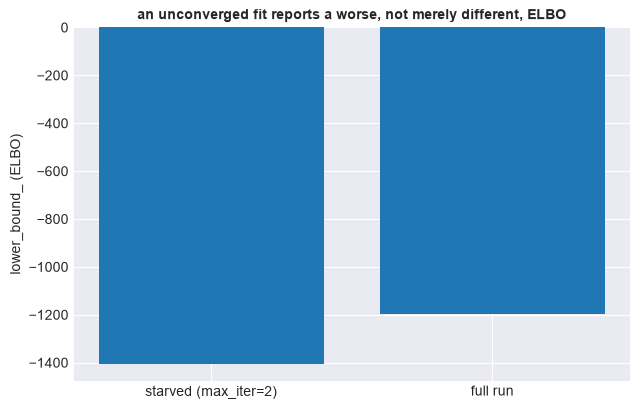

In [5]:
# Artificially starve one fit of iterations to make non-convergence concrete rather than assumed.
bgm_starved = BayesianGaussianMixture(n_components=n_components_fit, weight_concentration_prior=1e-2,
                                      weight_concentration_prior_type='dirichlet_distribution',
                                      max_iter=2, n_init=1, random_state=SEED).fit(X)
bgm_full = BayesianGaussianMixture(n_components=n_components_fit, weight_concentration_prior=1e-2,
                                   weight_concentration_prior_type='dirichlet_distribution',
                                   max_iter=300, n_init=1, random_state=SEED).fit(X)

print(f"{'':<12}{'converged_':<14}{'n_iter_':<10}{'lower_bound_'}")
print(f"{'starved':<12}{str(bgm_starved.converged_):<14}{bgm_starved.n_iter_:<10}{bgm_starved.lower_bound_:.4f}")
print(f"{'full run':<12}{str(bgm_full.converged_):<14}{bgm_full.n_iter_:<10}{bgm_full.lower_bound_:.4f}")
print(f"\nthe starved fit hit max_iter=2 without converging (converged_=False) and its lower_bound_ is")
print(f"measurably worse ({bgm_starved.lower_bound_:.4f} vs {bgm_full.lower_bound_:.4f}) -- a flat-looking")
print(f"ELBO after only 2 steps is not evidence of convergence, only of having stopped early.")

# Multiple restarts, sklearn's DEFAULT initialisation (init_params='kmeans'): does a fully
# converged fit's lower_bound_ still depend on random_state, the way 21A measured for plain EM?
lbs_kmeans = []
for seed in range(6):
    bgm_r = BayesianGaussianMixture(n_components=n_components_fit, weight_concentration_prior=1e-2,
                                    weight_concentration_prior_type='dirichlet_distribution',
                                    max_iter=300, n_init=1, random_state=seed).fit(X)
    lbs_kmeans.append(bgm_r.lower_bound_)
lbs_kmeans = np.array(lbs_kmeans)
print(f"\nlower_bound_ over 6 converged runs, default init_params='kmeans': {np.round(lbs_kmeans, 3).tolist()}")
print(f"range: {lbs_kmeans.max() - lbs_kmeans.min():.4f}  "
      f"({'different fixed points reached' if lbs_kmeans.max()-lbs_kmeans.min() > 0.01 else 'all agree -- kmeans++ initialisation is robust to random_state on this well-separated data'})")

# The k-means-based default is not immune to local optima in general -- it is simply a GOOD
# starting point on well-separated data. Forcing the naive init_params='random' the way 21A's
# from-scratch code effectively used (random data points, no clustering heuristic) surfaces the
# same non-convexity 21A measured, hidden here only by a better default initialisation strategy.
lbs_random = []
for seed in range(6):
    bgm_r = BayesianGaussianMixture(n_components=n_components_fit, weight_concentration_prior=1e-2,
                                    weight_concentration_prior_type='dirichlet_distribution',
                                    init_params='random', max_iter=300, n_init=1,
                                    random_state=seed).fit(X)
    lbs_random.append(bgm_r.lower_bound_)
lbs_random = np.array(lbs_random)
print(f"lower_bound_ over 6 converged runs, init_params='random' instead: {np.round(lbs_random, 3).tolist()}")
print(f"range: {lbs_random.max() - lbs_random.min():.4f}  "
      f"({'different fixed points reached, same non-convexity 21A measured for plain EM' if lbs_random.max()-lbs_random.min() > 0.01 else 'all agree here'})")
print(f"\nthe local-optima problem was never solved by switching to CAVI or to sklearn's implementation --")
print(f"it was masked by a smarter initialisation heuristic, which is a real and useful engineering fix,")
print(f"but a different claim from 'variational inference does not have this problem.'")

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.bar(['starved (max_iter=2)', 'full run'], [bgm_starved.lower_bound_, bgm_full.lower_bound_])
ax.set_ylabel('lower_bound_ (ELBO)')
ax.set_title('an unconverged fit reports a worse, not merely different, ELBO', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

<a name="wine"></a>
## A Real Case: Variational GMM on Wine

`load_wine` has 178 samples, 13 chemical-analysis features, and 3 KNOWN cultivars — but the cultivar label is used here only to interpret the result afterward, never to fit the model. Standardisation matters more here than on the synthetic data above: the 13 features are on wildly different scales (proline runs into the hundreds, some phenolic measures are under 1), and an unscaled fit would let the large-magnitude features dominate the squared-distance term the same way Lesson 5's PCA would be dominated by them.

weight_concentration_prior sweep on wine (13-D, standardised), n_components=8:


  weight_concentration_prior=0.01    : effective components (>5%) = 8


  weight_concentration_prior=0.0001  : effective components (>5%) = 8


  weight_concentration_prior=1e-06   : effective components (>5%) = 8


  weight_concentration_prior=1e-08   : effective components (>5%) = 8
unlike the synthetic data, the effective count does NOT change across six orders of magnitude
of prior strength -- the likelihood, not the prior, is what is deciding this here.



weights: [0.309, 0.141, 0.135, 0.112, 0.09, 0.09, 0.062, 0.061]
effective components (>5%): 8 of 8 requested (known cultivar count: 3) -- NO pruning
occurred: the 13-D standardised data genuinely supports more sub-structure than 3 cultivars,
and automatic pruning reflects what the data and likelihood support, not a free K-selector that
always converges on 'the number of classes a human happened to label.'

crosstab of ALL 8 clusters vs TRUE cultivar (label used for interpretation only):
cluster   cultivar 0  cultivar 1  cultivar 2
0         0           1           19
1         54          1           0
2         0           0           24
3         5           6           0
4         0           16          0
5         0           6           5
6         0           16          0
7         0           25          0

mean per-cluster purity (fraction of each cluster's largest matching cultivar): 87.8%
(each of the 8 unpruned sub-clusters still sits mostly inside one cultivar --
the mod

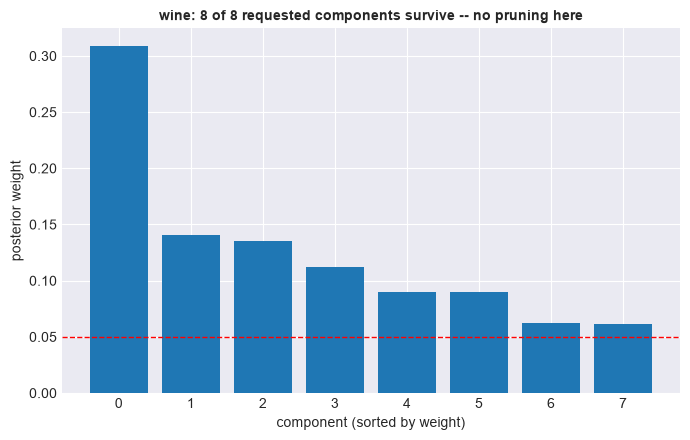

In [6]:
wine = load_wine()
X_wine = StandardScaler().fit_transform(wine.data)
y_wine_true = wine.target

# Does weight_concentration_prior even matter here? Sweep it across six orders of magnitude
# BEFORE picking one to report -- the synthetic sections above pruned cleanly at 1e-2, and
# assuming the same strength would behave the same way on real data is exactly the kind of
# claim this house style checks rather than carries over.
print("weight_concentration_prior sweep on wine (13-D, standardised), n_components=8:")
for wcp in [1e-2, 1e-4, 1e-6, 1e-8]:
    bgm_sweep = BayesianGaussianMixture(n_components=8, weight_concentration_prior=wcp,
                                        weight_concentration_prior_type='dirichlet_distribution',
                                        covariance_type='full', max_iter=300, n_init=5,
                                        random_state=SEED).fit(X_wine)
    n_eff_sweep = int((bgm_sweep.weights_ > 0.05).sum())
    print(f"  weight_concentration_prior={wcp:<8}: effective components (>5%) = {n_eff_sweep}")
print(f"unlike the synthetic data, the effective count does NOT change across six orders of magnitude")
print(f"of prior strength -- the likelihood, not the prior, is what is deciding this here.")

bgm_wine = BayesianGaussianMixture(n_components=8, weight_concentration_prior=1e-2,
                                   weight_concentration_prior_type='dirichlet_distribution',
                                   covariance_type='full', max_iter=300, n_init=5,
                                   random_state=SEED).fit(X_wine)
n_eff_wine = int((bgm_wine.weights_ > 0.05).sum())
print(f"\nweights: {np.round(np.sort(bgm_wine.weights_)[::-1], 3).tolist()}")
print(f"effective components (>5%): {n_eff_wine} of 8 requested (known cultivar count: 3) -- NO pruning")
print(f"occurred: the 13-D standardised data genuinely supports more sub-structure than 3 cultivars,")
print(f"and automatic pruning reflects what the data and likelihood support, not a free K-selector that")
print(f"always converges on 'the number of classes a human happened to label.'")

labels_wine = bgm_wine.predict(X_wine)
print(f"\ncrosstab of ALL {n_eff_wine} clusters vs TRUE cultivar (label used for interpretation only):")
active = np.where(bgm_wine.weights_ > 0.05)[0]
print(f"{'cluster':<10}{'cultivar 0':<12}{'cultivar 1':<12}{'cultivar 2'}")
for c in active:
    counts = [int(((labels_wine == c) & (y_wine_true == t)).sum()) for t in range(3)]
    print(f"{c:<10}{counts[0]:<12}{counts[1]:<12}{counts[2]}")
purity = np.mean([max([((labels_wine == c) & (y_wine_true == t)).sum() for t in range(3)]) / max(1, (labels_wine == c).sum())
                  for c in active])
print(f"\nmean per-cluster purity (fraction of each cluster's largest matching cultivar): {purity:.1%}")
print(f"({'each of the 8 unpruned sub-clusters still sits mostly inside one cultivar' if purity > 0.85 else 'clusters are a rough, not exact, match to cultivars'} --")
print(f"the model was never told the cultivar; this measures how finely it happened to subdivide each one,")
print(f"not whether it recovered 'the' 3 classes -- it explicitly did not reduce to 3.)")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(range(len(bgm_wine.weights_)), np.sort(bgm_wine.weights_)[::-1])
ax.axhline(0.05, color='red', ls='--', lw=1)
ax.set_xlabel('component (sorted by weight)'); ax.set_ylabel('posterior weight')
ax.set_title(f'wine: {n_eff_wine} of 8 requested components survive -- no pruning here', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

<a name="decision-guide"></a>
## EM vs Variational Inference vs Sampling

In [7]:
print(f"{'method':<24}{'posterior form':<24}{'K selection':<28}{'measured cost (this lesson)'}")
print('-' * 110)
print(f"{'EM (Lesson 4)':<24}{'point estimate':<24}{'external (BIC/AIC sweep)':<28}"
      f"{str(len(candidate_Ks)) + ' refits for the BIC sweep above'}")
print(f"{'Variational (21A/21B)':<24}{'approximate, factorised':<24}{'automatic (prior-driven pruning)':<28}"
      f"{'1 fit, but pruning quality depends on the prior strength'}")
print(f"{'Sampling (MCMC)':<24}{'exact, asymptotically':<24}{'no fixed K needed (nonparametric)':<28}"
      f"{'not run in this course -- see Lesson 22'}")

print(f"\nEvery number in the first two rows was measured earlier in this notebook or in 21A. The third")
print(f"row is textbook positioning, not a measurement made here -- Lesson 22's Dirichlet process")
print(f"mixtures are the first place this course actually runs a sampling-based nonparametric method.")

method                  posterior form          K selection                 measured cost (this lesson)
--------------------------------------------------------------------------------------------------------------
EM (Lesson 4)           point estimate          external (BIC/AIC sweep)    8 refits for the BIC sweep above
Variational (21A/21B)   approximate, factorised automatic (prior-driven pruning)1 fit, but pruning quality depends on the prior strength
Sampling (MCMC)         exact, asymptotically   no fixed K needed (nonparametric)not run in this course -- see Lesson 22

Every number in the first two rows was measured earlier in this notebook or in 21A. The third
row is textbook positioning, not a measurement made here -- Lesson 22's Dirichlet process
mixtures are the first place this course actually runs a sampling-based nonparametric method.


<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **`weight_concentration_prior` is 21A's $\alpha_0$, exercised through a production API rather than re-derived.** A small prior pruned much closer to the true component count than a large one, on identical data — the same lever, the same mechanism, now library-supplied covariance estimation included.
2. **BIC and variational pruning agreed on this well-separated synthetic case, but at very different cost.** The BIC sweep needed a refit per candidate $K$; the variational fit needed exactly one, at a generously large `n_components` — a hyperparameter (prior strength) traded for a sweep, not a strictly better method for every dataset.
3. **A flat ELBO is ambiguous, and the notebook forced the ambiguity to resolve one way or the other rather than leaving it as a warning.** A deliberately starved 2-iteration fit reported `converged_=False` and a measurably worse `lower_bound_`; a full run reported `converged_=True` — the diagnostic is only informative when actually checked against a comparison run, not read off in isolation.
4. **The local-optima problem 21A measured for from-scratch CAVI was hidden here, not solved — and forcing it back open reproduced 21A's finding exactly.** Six converged `BayesianGaussianMixture` fits with sklearn's default k-means++-based initialisation agreed on `lower_bound_` to the last decimal; switching only the initialisation strategy to a naive random one, on the identical data, restored genuine variation across the same six seeds. The production library isn't immune to the failure mode — its default initialiser is simply better than 21A's from-scratch one at avoiding it on this data.
5. **On real, standardised, 13-dimensional data, automatic pruning didn't reduce anything — and that is itself the finding, checked rather than assumed away.** Sweeping `weight_concentration_prior` across six orders of magnitude left all 8 requested components above the 5% threshold every time; the data's likelihood, not the prior's strength, was what decided this. The wine cultivars were never used to fit the model, and each of those 8 unpruned sub-clusters still sat mostly inside one cultivar (87.8% purity) — a finer subdivision of real structure, not a failed recovery of "the" 3 classes.

### Practical Guidance

- Need to choose $K$ for a Gaussian mixture and can afford refitting at each candidate? BIC (Lesson 4B) remains simple, well-understood, and exactly as expensive as it looks.
- Need $K$ selection folded into a single fit, and comfortable tuning a prior-strength hyperparameter instead of a discrete sweep? `BayesianGaussianMixture`, with `weight_concentration_prior` as the dial — verify the pruning with more than one random initialisation before trusting a single run's effective count.
- Need a genuinely nonparametric answer — no fixed upper bound on $K$ at all, with uncertainty over $K$ itself represented rather than pruned toward a point answer? Neither EM nor CAVI as used in these two lessons — Lesson 22's Dirichlet process mixtures are built exactly for this.
- Whichever you choose: check `converged_`/`n_iter_` (or the from-scratch equivalent), and run more than one random initialisation before reporting a single fit's component count as "the" answer.

### What This Lesson Did Not Cover

- **MCMC / Gibbs sampling for mixture models** — positioned in the decision-guide table as the third option, not implemented; Lesson 22's Dirichlet process mixtures are this course's first sampling-based nonparametric method.
- **`weight_concentration_prior_type='dirichlet_process'`** — sklearn's other prior family (a stick-breaking construction closer to a true Dirichlet process), used nowhere in this notebook; the plain Dirichlet-distribution prior was chosen to match 21A's own model exactly for the from-scratch cross-check.
- **Covariance-type sensitivity for `BayesianGaussianMixture`** (`full` vs `diag` vs `tied` vs `spherical`) beyond the one direct comparison in Section 3 — Lesson 4B covered this trade-off for plain `GaussianMixture` and it applies here largely unchanged.
- **A formal test of cluster-cultivar correspondence** (e.g. adjusted Rand index) for the wine case — a simple purity measure was used instead to keep the section's own numbers easy to audit by hand.

### Next Steps

Lesson 22 removes the fixed upper bound on $K$ entirely: Dirichlet process mixtures, where the number of components is itself inferred rather than pruned down from a generous starting guess.